# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 10     |  |
| :-------------|:-------------|
| Siemen Spek| 6579531 |
| Tom Jongbloed| 6581048 |
| Batu Sönmez| 6175163 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Siemen Spek', 'Tom Jongbloed','Batu Sönmez']

## Opdracht 1: Planning.

| Planning Groep: 10     |Tijdstip / Tijdspanne  |
|---|---|
| pull request gemaakt | 11.30 |
| kalibratie arduinometing | 12.15 |
| testen meetopstelling | 12.45 |
| pauze 1 | 12.45 - 13.45 |
| pauze 2| 16.00 - 16.30 |
| eerste algoritme ideeen| 14.00 |
| iteratie 0 | 14.30 |
| iteratie 1 | 15.00 |
| opdracht af | 17.45 |

## Opdracht 2: Import libs.

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
from scipy.optimize import curve_fit

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [10]
<img src="kalibratie_opstelling.jpeg" width="400">

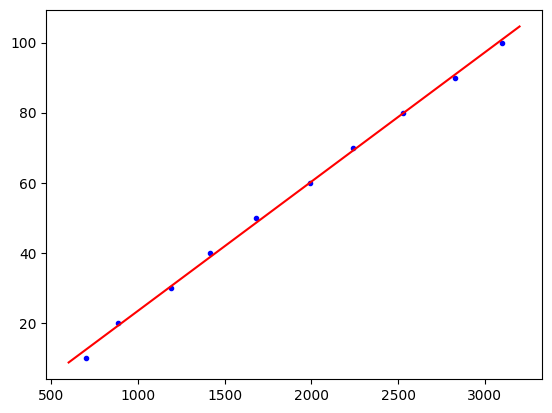

 a = 0.03688
 b = -13.43215


In [20]:
# verwerk hier jullie kalibratiemetingen
kalibratie_bits = np.array([700,886,1189,1413,1680,1992,2242,2530,2825,3100 ])
kalibratie_afstand = np.array([10,20,30,40,50,60,70,80,90,100])


def function(x,a,b):
    return a*x+b

values, covariance = curve_fit(function,kalibratie_bits,kalibratie_afstand)

x_fit = np.linspace(600,3200,300)

plt.figure()
plt.plot(kalibratie_bits,kalibratie_afstand,'b.')
plt.plot(x_fit, function(x_fit,*values),'r-')
plt.show()
print(f' a = {values[0]:.5f}')
print(f' b = {values[1]:.5f}')

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  40   0  30  45.65
1   0  30   0  20  45.02
2  40   0  30   0  40.00
3  30   0  20   0  40.74


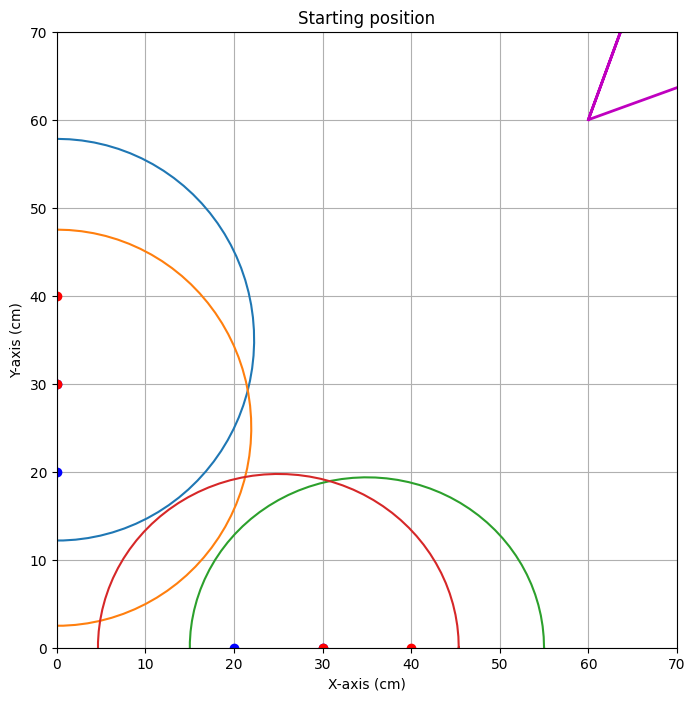


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=99.102


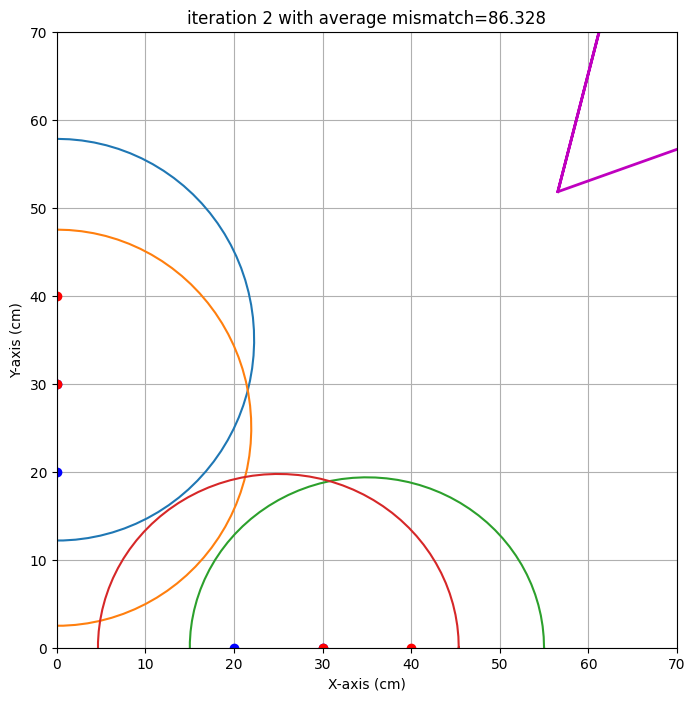

end iteration 2 with average mismatch=86.328


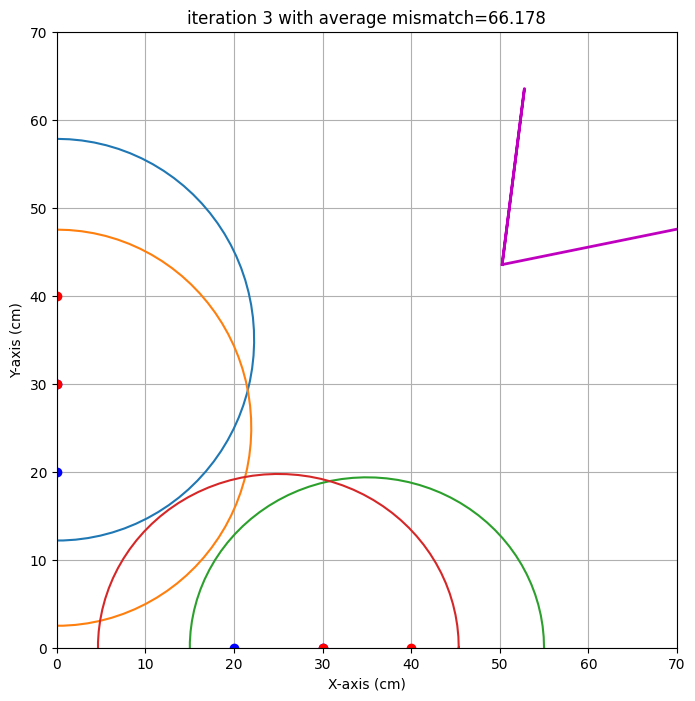

end iteration 3 with average mismatch=66.178


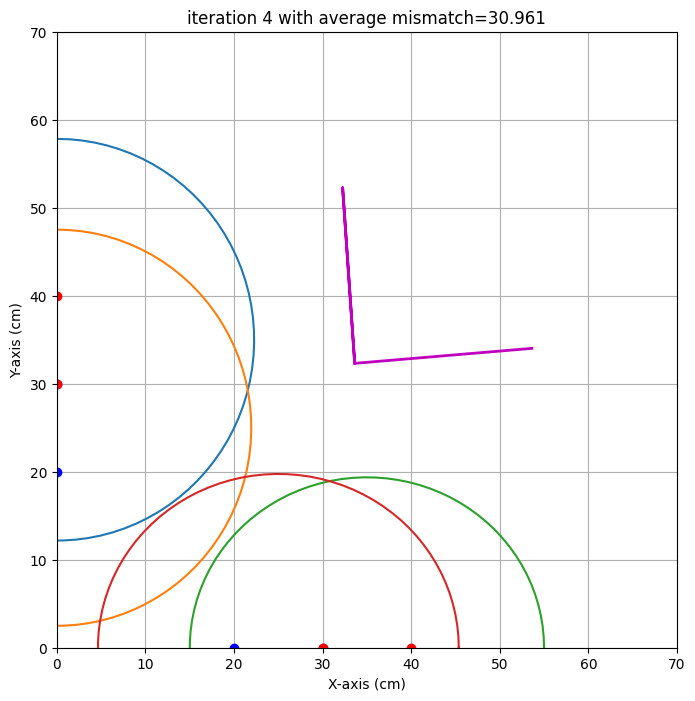

end iteration 4 with average mismatch=30.961


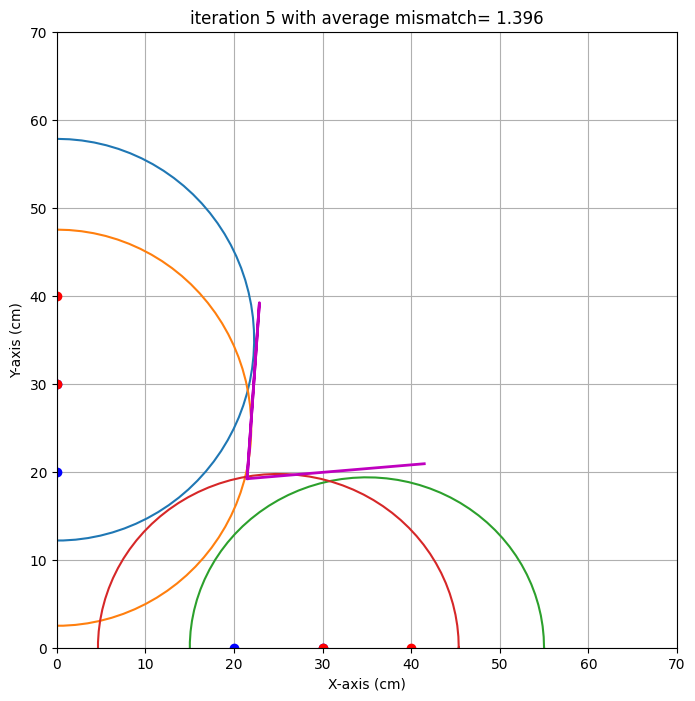

end iteration 5 with average mismatch= 1.396


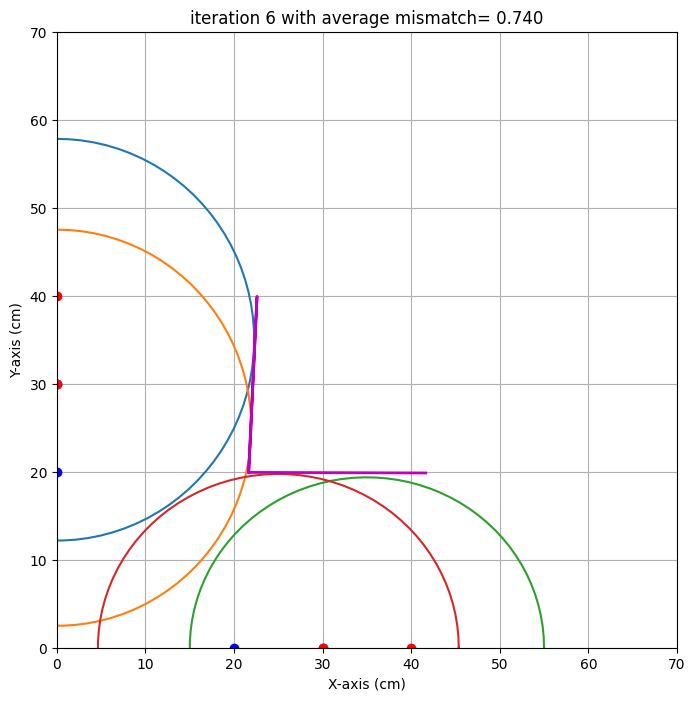

end iteration 6 with average mismatch= 0.740


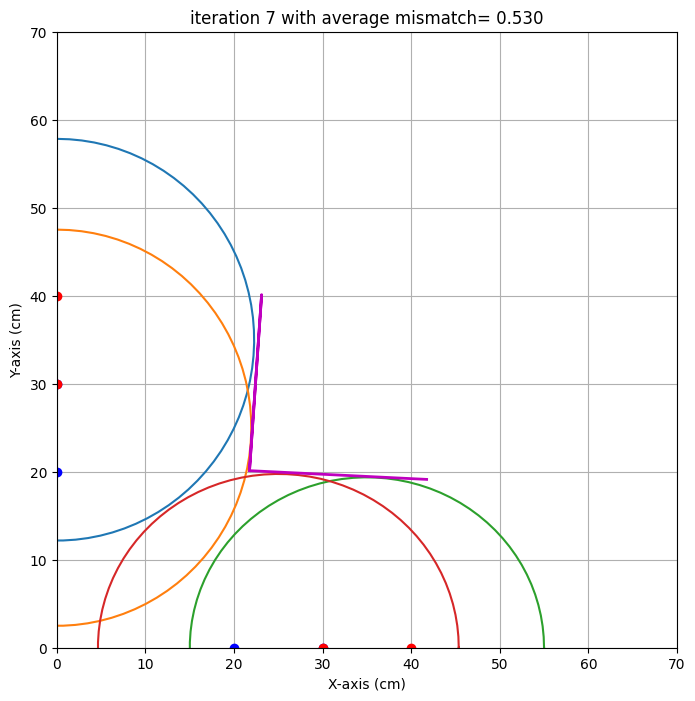

end iteration 7 with average mismatch= 0.530
end iteration 8 with average mismatch= 0.483
end iteration 9 with average mismatch= 0.467


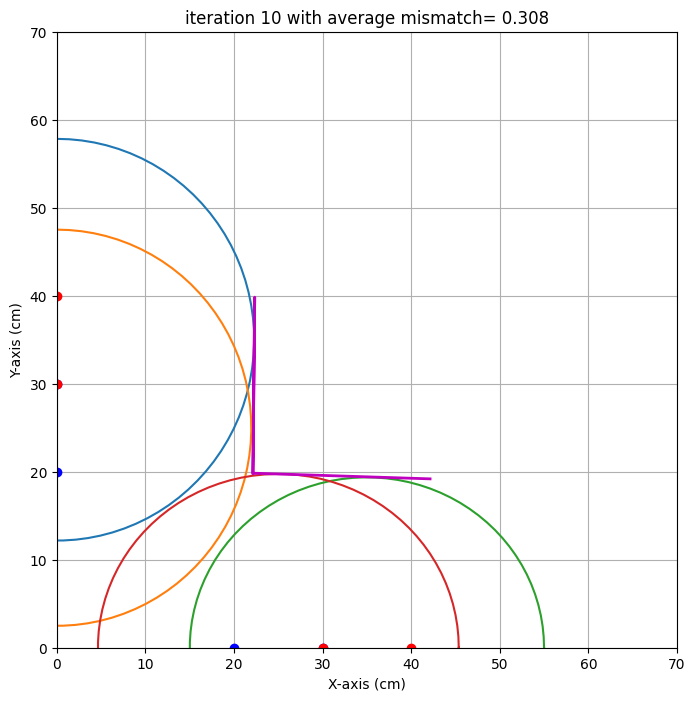

end iteration 10 with average mismatch= 0.308
end iteration 11 with average mismatch= 0.291
end iteration 12 with average mismatch= 0.291
end iteration 13 with average mismatch= 0.291
end iteration 14 with average mismatch= 0.291
end iteration 15 with average mismatch= 0.291
end iteration 16 with average mismatch= 0.291
end iteration 17 with average mismatch= 0.291
end iteration 18 with average mismatch= 0.291
end iteration 19 with average mismatch= 0.291
end iteration 20 with average mismatch= 0.291
end iteration 21 with average mismatch= 0.291
end iteration 22 with average mismatch= 0.291
end iteration 23 with average mismatch= 0.291
end iteration 24 with average mismatch= 0.291
end iteration 25 with average mismatch= 0.291
end iteration 26 with average mismatch= 0.291
end iteration 27 with average mismatch= 0.291
end iteration 28 with average mismatch= 0.291
end iteration 29 with average mismatch= 0.291
Last iteration, also determine uncertainty, wait a while..
wait a little longer.

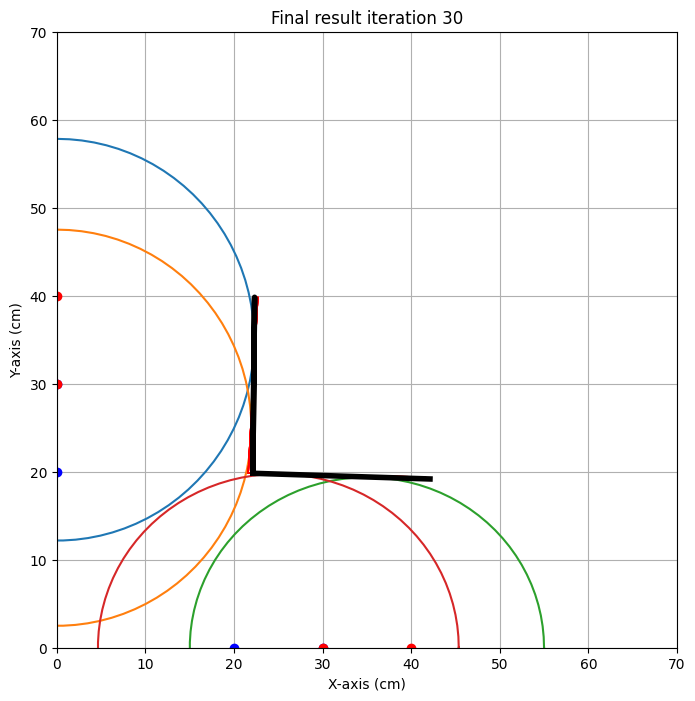

In [24]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,45.65],
    [0,30,0,20,45.02],
    [40,0,30,0,40],
    [30,0,20,0,40.74],  
    ])
# [10,0,0,10,]  meting buiten beschouwing gelaten omdat hier de hoek wordt gemeten.
# [10,0,20,0,43.2], 
# 
resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [25]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 22.1 cm met een standaardafwijking van 0.5 cm 
y0: 19.8 cm met een standaardafwijking van 0.0 cm 
alpha: -1.8 graden met een standaardafwijking van 0.5 graad 
beta: 0.6 graden met een standaardafwijking van 2.5 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Siemen Spek]
<img src="eerste_algoritme_siemen.jpeg" width="400">

#### algoritme [Batu Sönmez]
<img src="eerste_algoritme_batu.jpeg" width="400">

#### algoritme [Tom Jongbloed]
<img src="eerste_algoritme_tom.jpeg" width="400">

In [28]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [43]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':40,  
           'y0': 45,
           'alpha' : 25,
           'beta' : 30,
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Siemen Spek' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # [0,30,0,35, ongeldig],
    # [0,45,0,50,ongeldig],
    [60,0,65,0, 93],
    [50,0,60,0, 88],
    #[30,0,35,0,ongeldig],
    [0,45,0,50,93],
    [0,50,0,55,90],
    # siemen
    ]),
       'Tom Jongbloed' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
      [65,0,55,0,87],
      [55,0,45,0,88.65],
      [0,75,0,65,102.3],
      [0,65,0,55,97],
    # tom
    ]),
       'naam3' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #zelf aanvullen
    ])
      }

## Opdracht 7: Evaluatie.

Siemen Spek
Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0  60   0  65   0  93
1  50   0  60   0  88
2   0  45   0  50  93
3   0  50   0  55  90


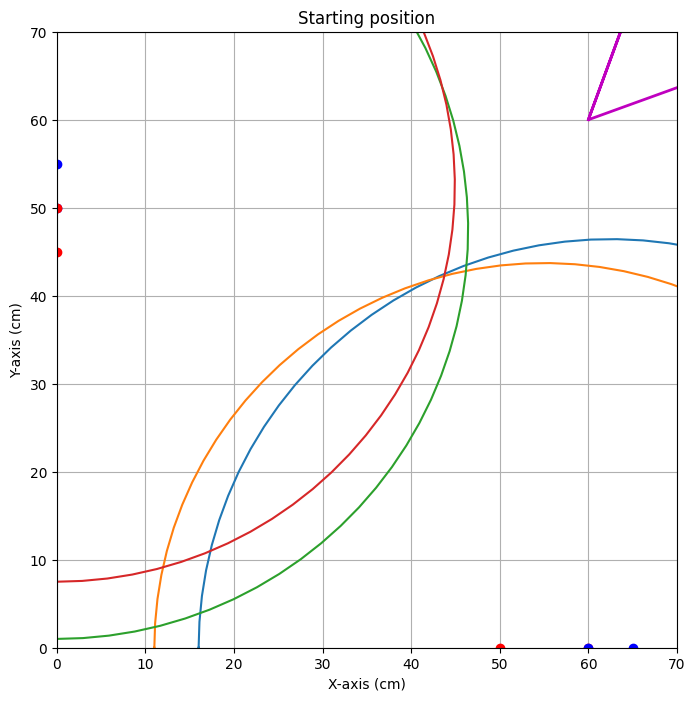


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=36.254


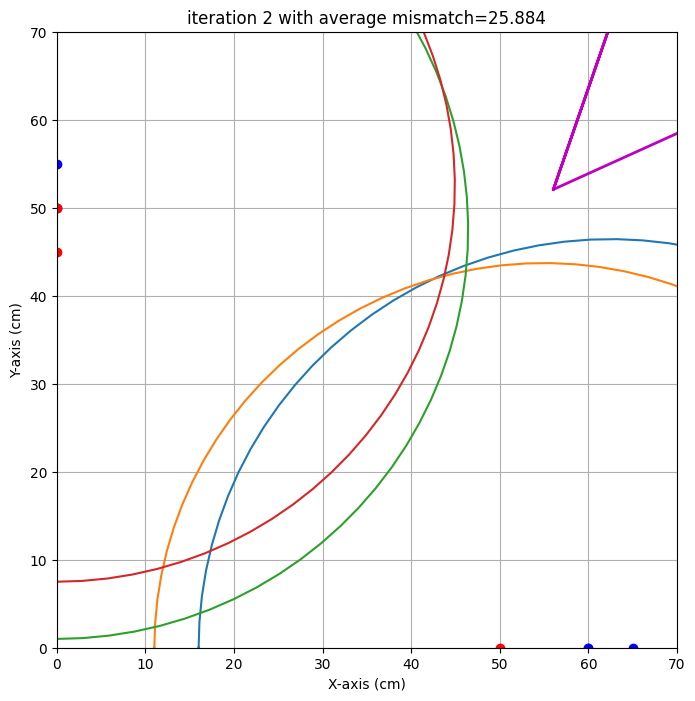

end iteration 2 with average mismatch=25.884


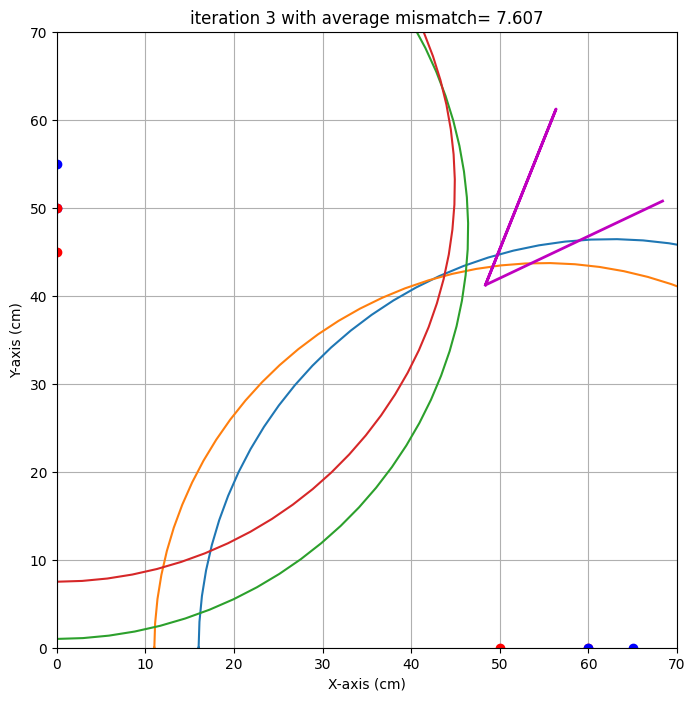

end iteration 3 with average mismatch= 7.607


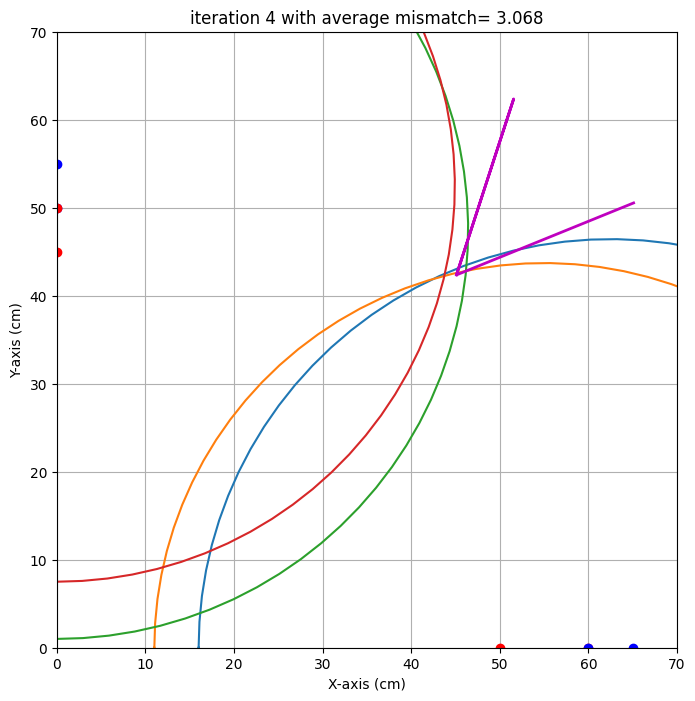

end iteration 4 with average mismatch= 3.068


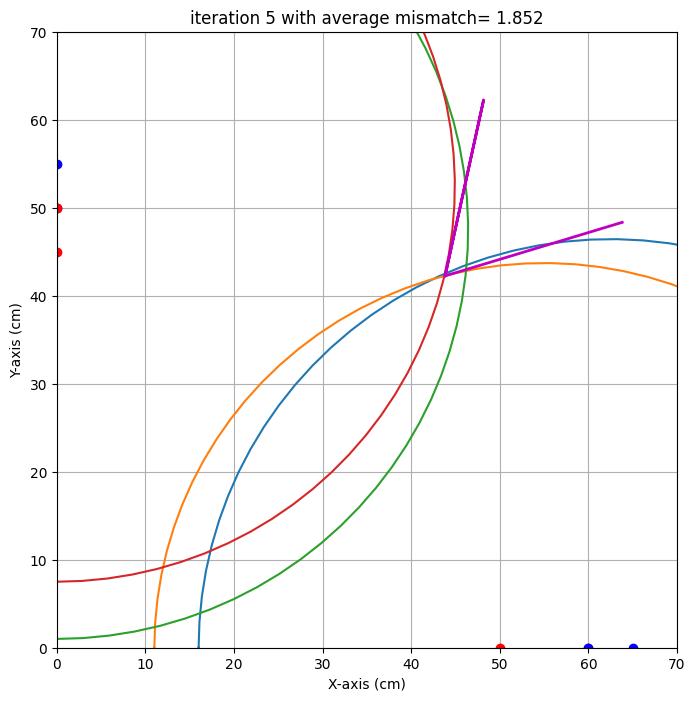

end iteration 5 with average mismatch= 1.852
end iteration 6 with average mismatch= 1.746
end iteration 7 with average mismatch= 1.746
end iteration 8 with average mismatch= 1.746
end iteration 9 with average mismatch= 1.746
end iteration 10 with average mismatch= 1.712
end iteration 11 with average mismatch= 1.650
end iteration 12 with average mismatch= 1.621
end iteration 13 with average mismatch= 1.530
end iteration 14 with average mismatch= 1.524
end iteration 15 with average mismatch= 1.503
end iteration 16 with average mismatch= 1.499
end iteration 17 with average mismatch= 1.499
end iteration 18 with average mismatch= 1.499
end iteration 19 with average mismatch= 1.499
end iteration 20 with average mismatch= 1.499
end iteration 21 with average mismatch= 1.499
end iteration 22 with average mismatch= 1.499
end iteration 23 with average mismatch= 1.499
end iteration 24 with average mismatch= 1.499
end iteration 25 with average mismatch= 1.499
end iteration 26 with average mismatch=

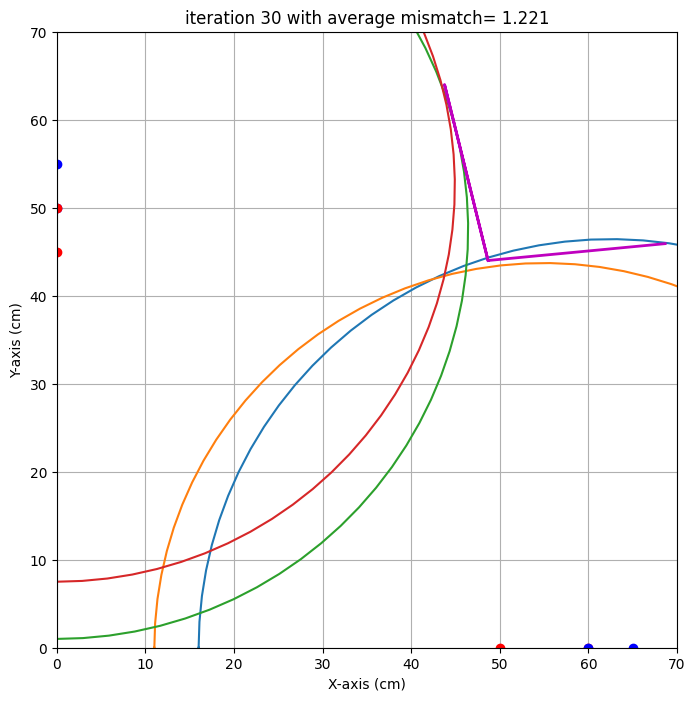

end iteration 30 with average mismatch= 1.221
###############################################################################
end of iteration  30
Best alpha=   5.47 with uncertainty=  10.24
Best beta = -13.80 with uncertainty=  12.07
Best x0   =  48.68 with uncertainty=   4.05
Best y0   =  44.00 with uncertainty=   1.68
###############################################################################


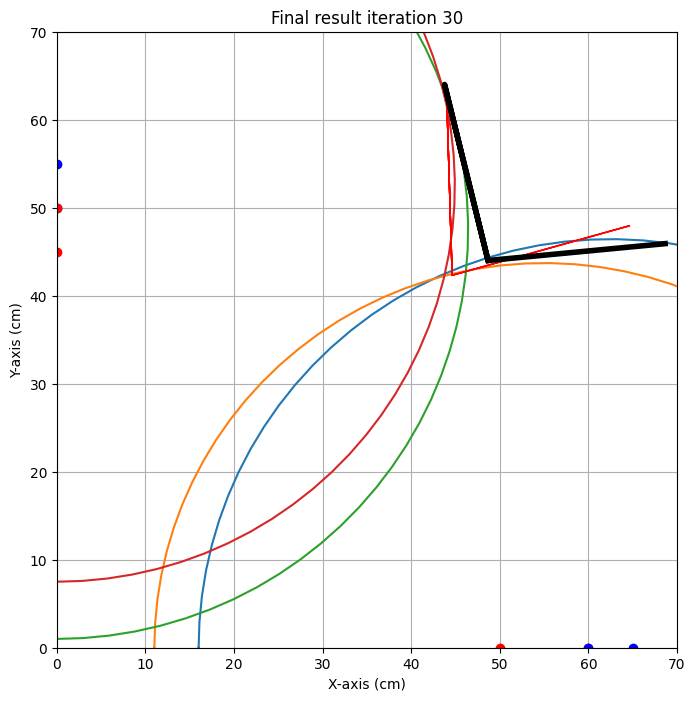

{'alpha': np.float64(5.469630746047765), 'alpha_eps': np.float64(10.239461544262557), 'beta': np.float64(-13.798745822433176), 'beta_eps': np.float64(12.067338018569503), 'x0': np.float64(48.675644380925746), 'x0_eps': np.float64(4.052622868417146), 'y0': np.float64(44.00207732918663), 'y0_eps': np.float64(1.6825290894848735)}
Tom Jongbloed
Running the imaging algorithm with the following data:
   xs  ys  xr  yr       R
0  65   0  55   0   87.00
1  55   0  45   0   88.65
2   0  75   0  65  102.30
3   0  65   0  55   97.00


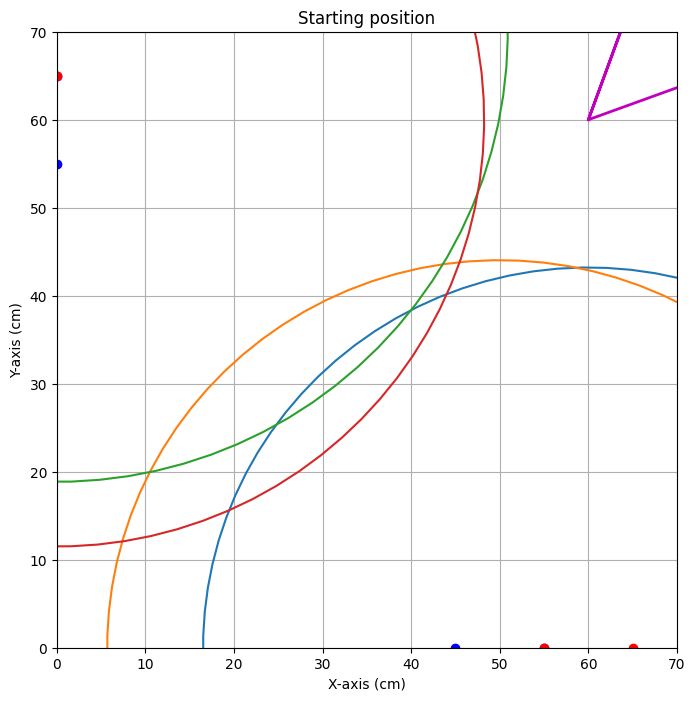


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=32.468


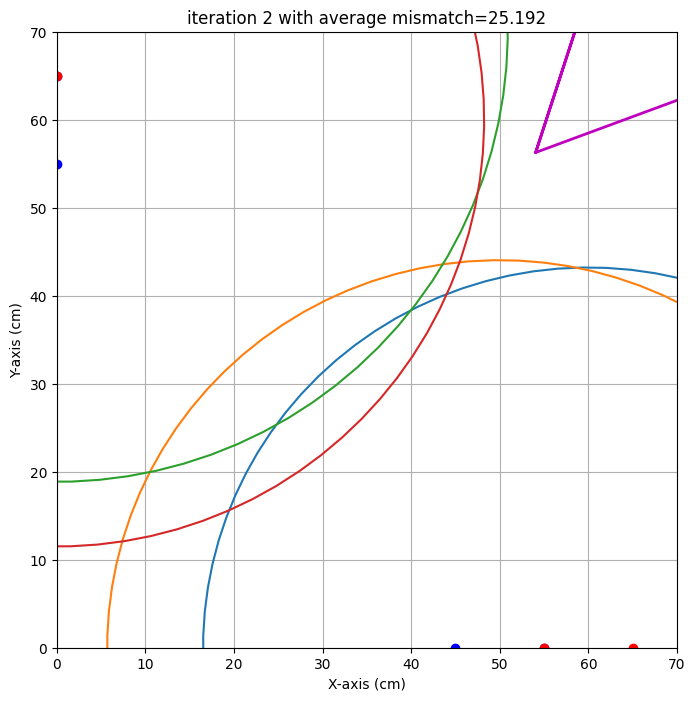

end iteration 2 with average mismatch=25.192


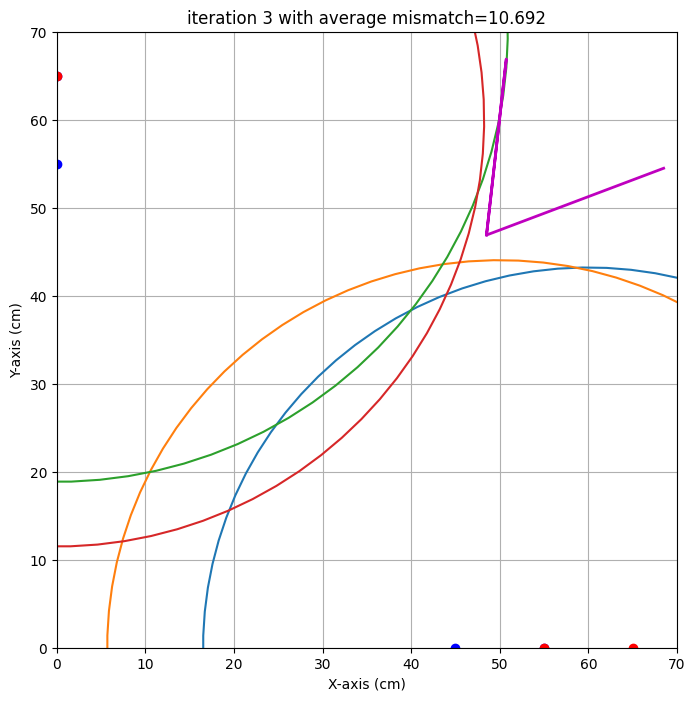

end iteration 3 with average mismatch=10.692


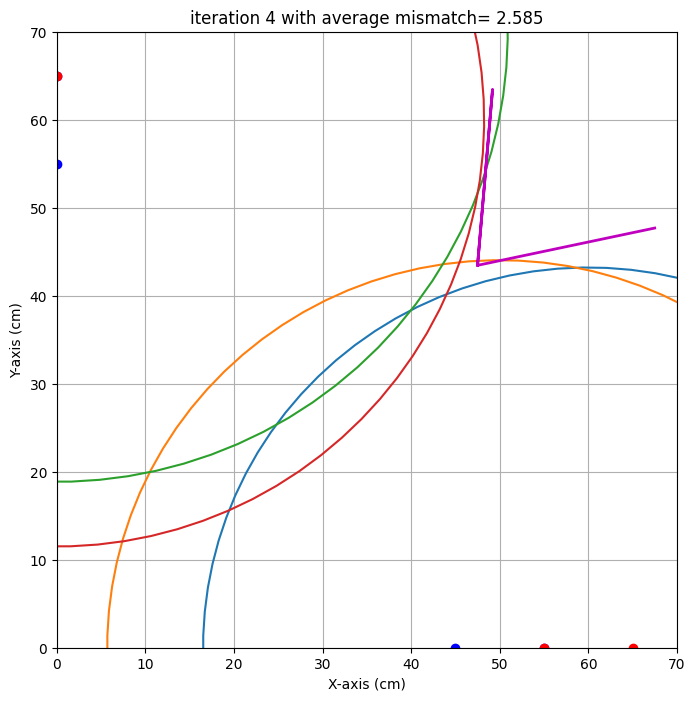

end iteration 4 with average mismatch= 2.585


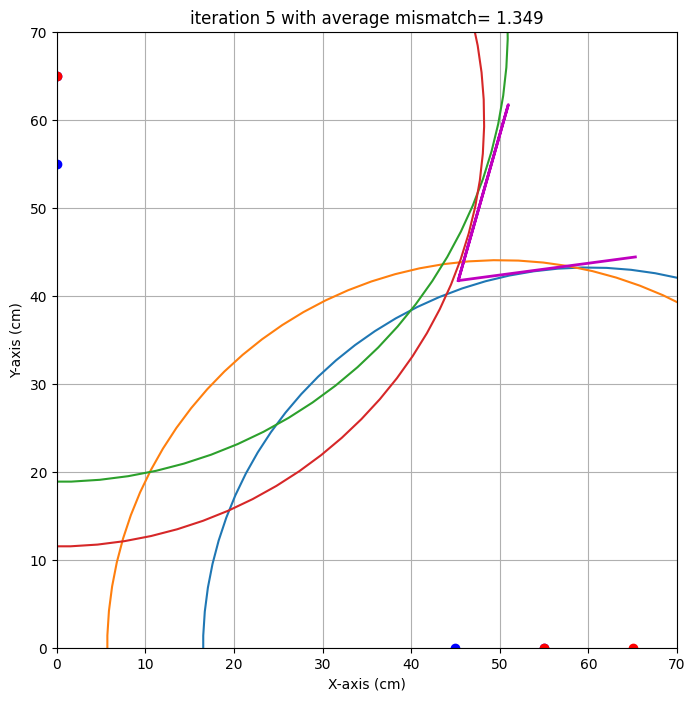

end iteration 5 with average mismatch= 1.349


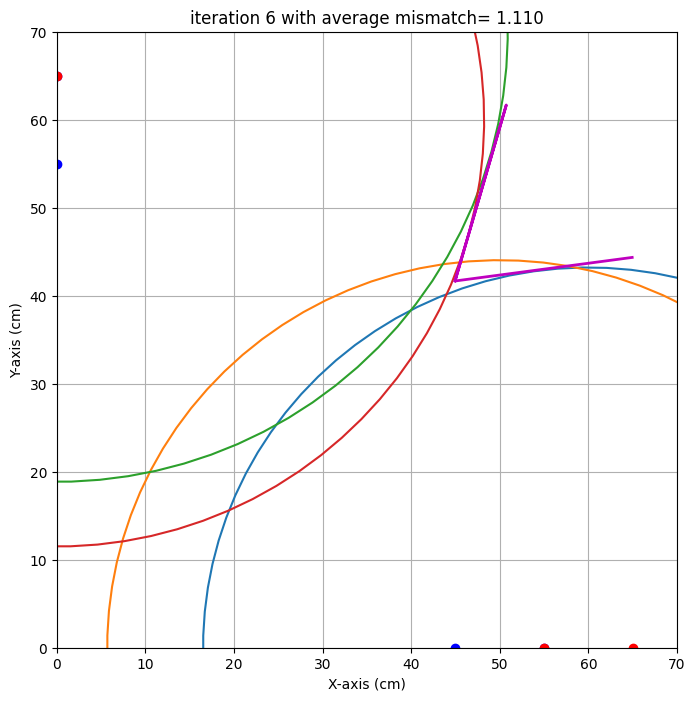

end iteration 6 with average mismatch= 1.110
end iteration 7 with average mismatch= 1.064
end iteration 8 with average mismatch= 1.051
end iteration 9 with average mismatch= 1.029
end iteration 10 with average mismatch= 1.029
end iteration 11 with average mismatch= 1.029
end iteration 12 with average mismatch= 1.029
end iteration 13 with average mismatch= 1.029
end iteration 14 with average mismatch= 1.029
end iteration 15 with average mismatch= 1.029
end iteration 16 with average mismatch= 0.975


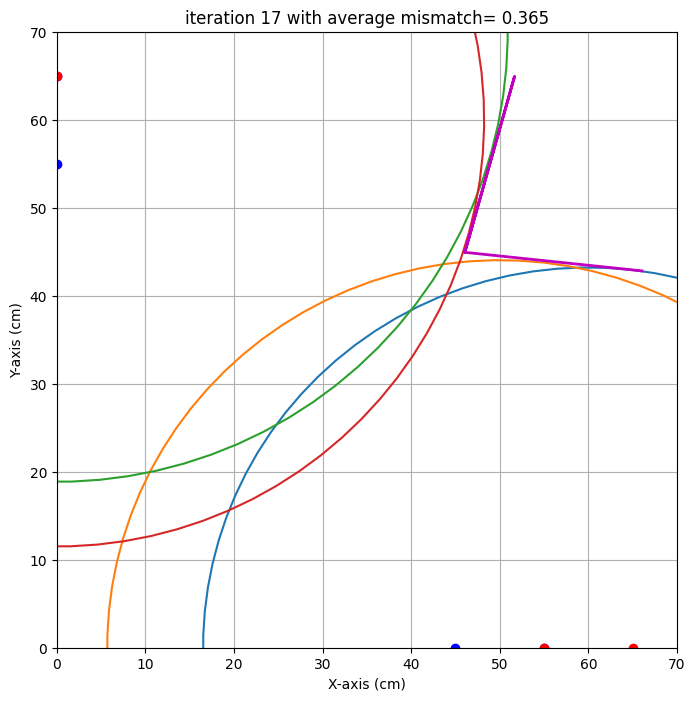

end iteration 17 with average mismatch= 0.365
end iteration 18 with average mismatch= 0.344


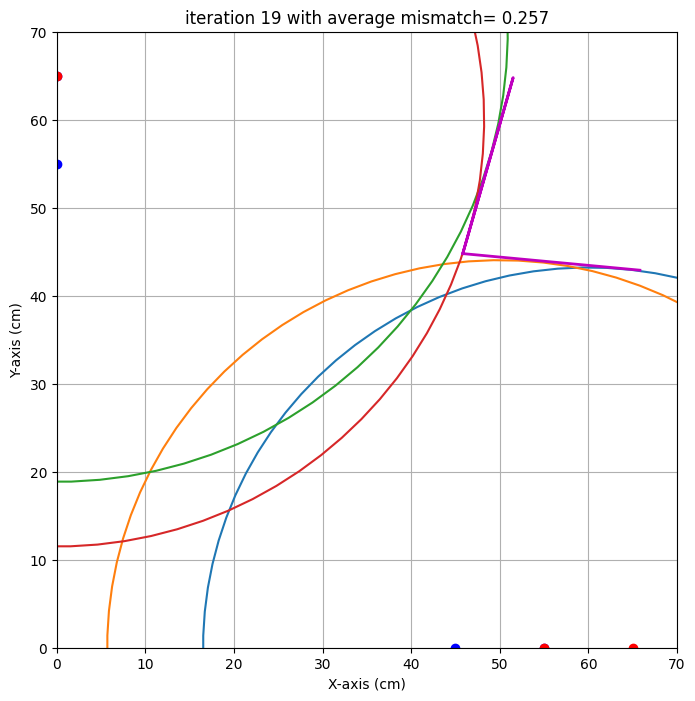

end iteration 19 with average mismatch= 0.257


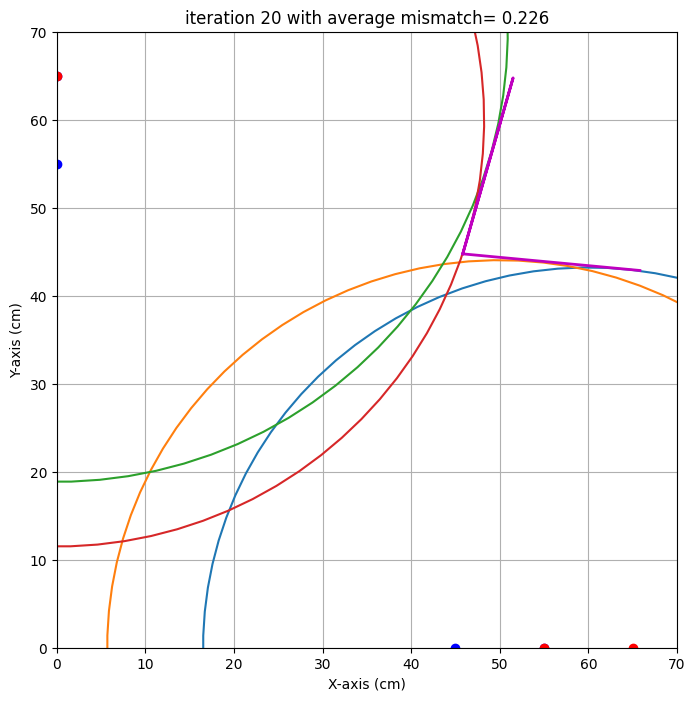

end iteration 20 with average mismatch= 0.226
end iteration 21 with average mismatch= 0.218
end iteration 22 with average mismatch= 0.214
end iteration 23 with average mismatch= 0.214
end iteration 24 with average mismatch= 0.214
end iteration 25 with average mismatch= 0.214
end iteration 26 with average mismatch= 0.214
end iteration 27 with average mismatch= 0.214
end iteration 28 with average mismatch= 0.214
end iteration 29 with average mismatch= 0.214
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.214
###############################################################################
end of iteration  30
Best alpha=  -5.40 with uncertainty=   3.75
Best beta =  15.87 with uncertainty=   1.18
Best x0   =  45.82 with uncertainty=   0.22
Best y0   =  44.75 with uncertainty=   0.65
###############################################################################


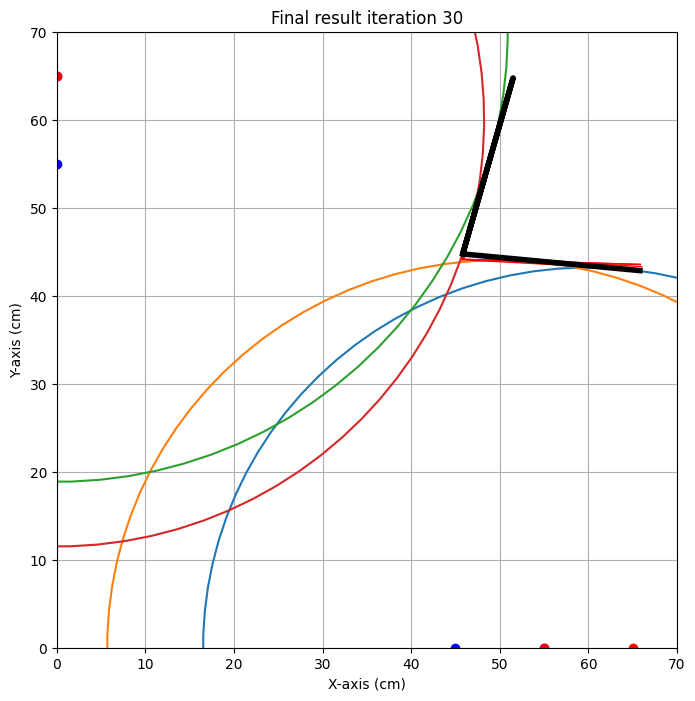

{'alpha': np.float64(-5.397391275114344), 'alpha_eps': np.float64(3.745278641714781), 'beta': np.float64(15.872786224995743), 'beta_eps': np.float64(1.1817952505412244), 'x0': np.float64(45.81930117466901), 'x0_eps': np.float64(0.21573811111714036), 'y0': np.float64(44.745474025929184), 'y0_eps': np.float64(0.6469471403872049)}
Batu Sönmez


KeyError: 'Batu Sönmez'

In [44]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [45]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Siemen Spek 
x0 target is : 40.0. Gevonden waarde: 48.7 cm met een standaardafwijking van 4.1 cm 
y0 target is : 45.0. Gevonden waarde: 44.0 cm met een standaardafwijking van 1.7 cm 
alpha target is : 25.0. Gevonden waarde: 5.5 graden met een standaardafwijking van 10.2 graad 
beta target is : 30.0. Gevonden waarde: -13.8 graden met een standaardafwijking van 12.1 graad 

Tom Jongbloed 
x0 target is : 40.0. Gevonden waarde: 45.8 cm met een standaardafwijking van 0.2 cm 
y0 target is : 45.0. Gevonden waarde: 44.7 cm met een standaardafwijking van 0.6 cm 
alpha target is : 25.0. Gevonden waarde: -5.4 graden met een standaardafwijking van 3.7 graad 
beta target is : 30.0. Gevonden waarde: 15.9 graden met een standaardafwijking van 1.2 graad 



KeyError: 'Batu Sönmez'

## Opdracht 8: Iteratie1+.14.45.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](iteratie_1.jpeg)


In [ ]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  50   0  40  62.00
1   0  55   0  35  67.00
2  40   0  30   0  68.88
3  45   0  25   0  74.00
4  50   0  20   0  80.00
5  55   0  15   0  86.00
6  60   0  10   0  91.00
7  65   0   5   0  96.00


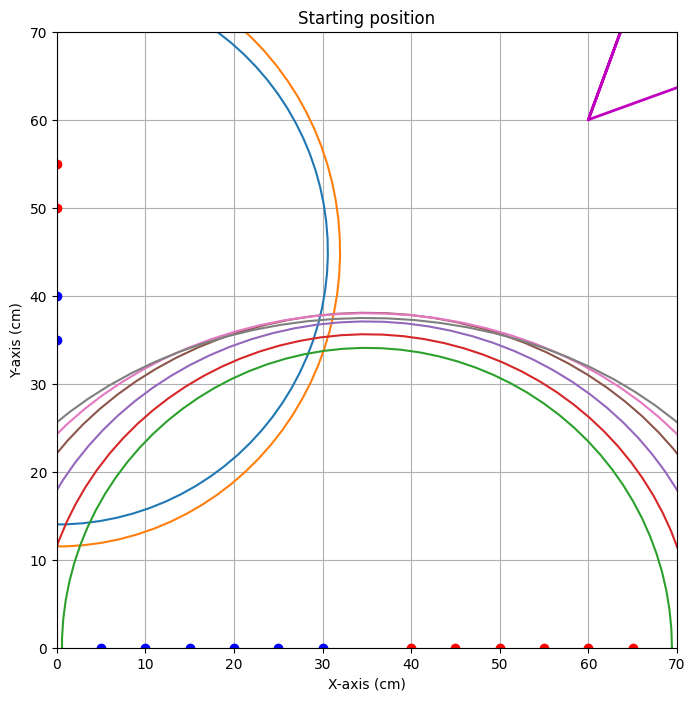


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=61.679


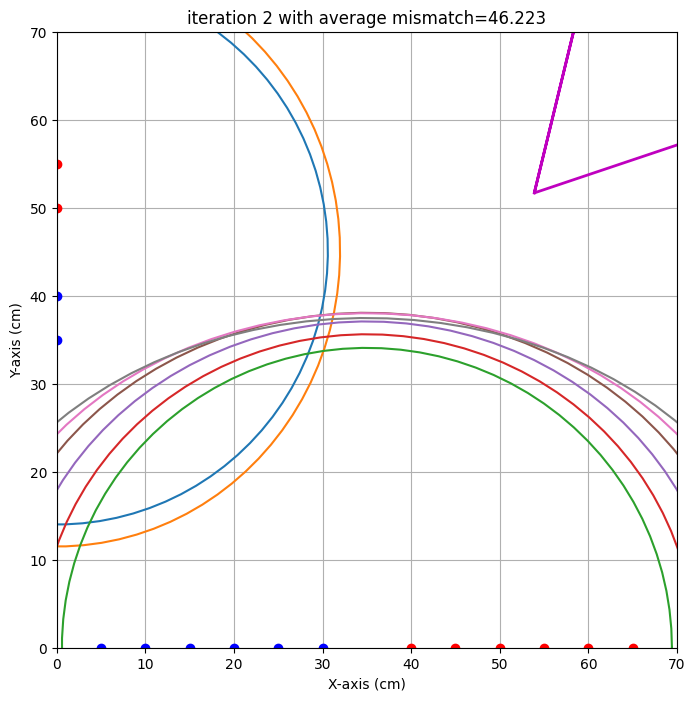

end iteration 2 with average mismatch=46.223


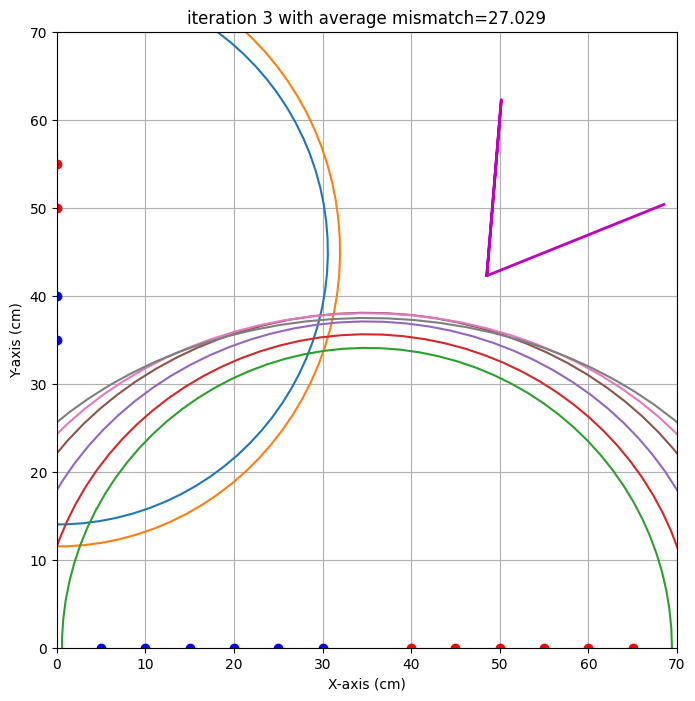

end iteration 3 with average mismatch=27.029


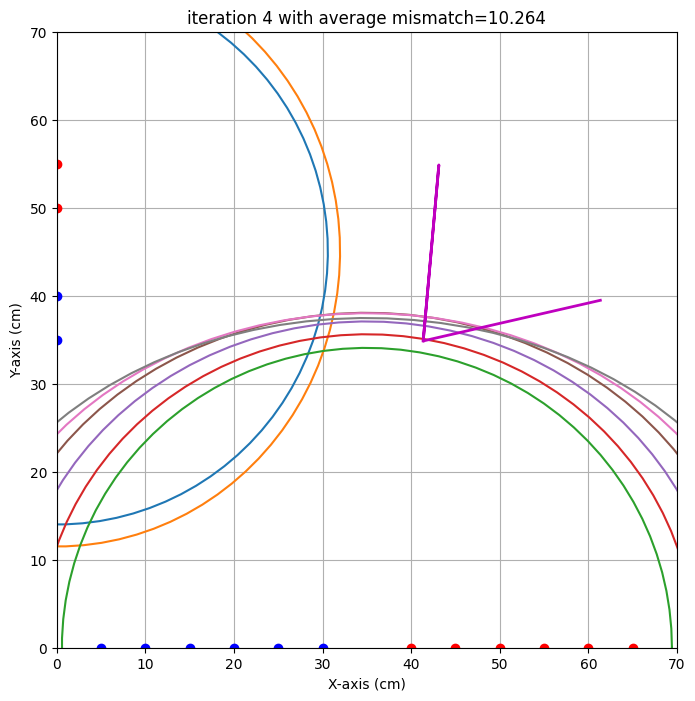

end iteration 4 with average mismatch=10.264


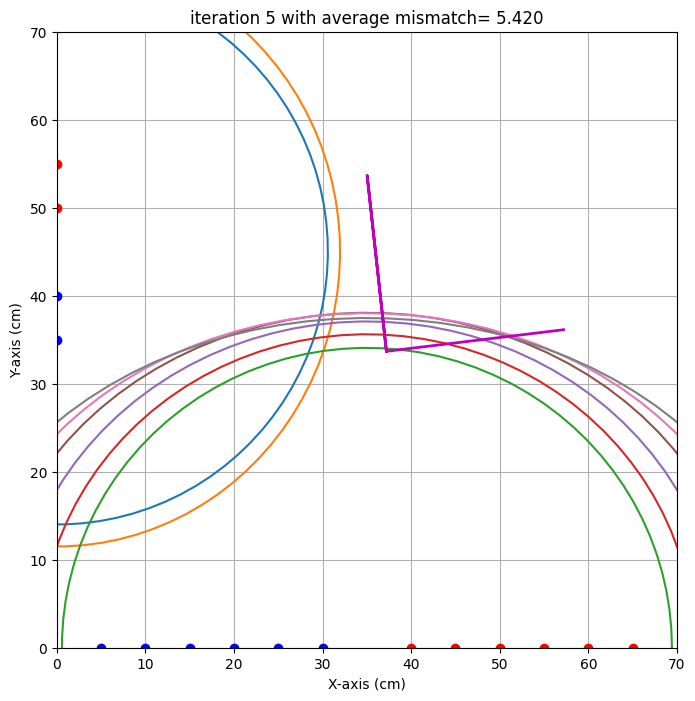

end iteration 5 with average mismatch= 5.420


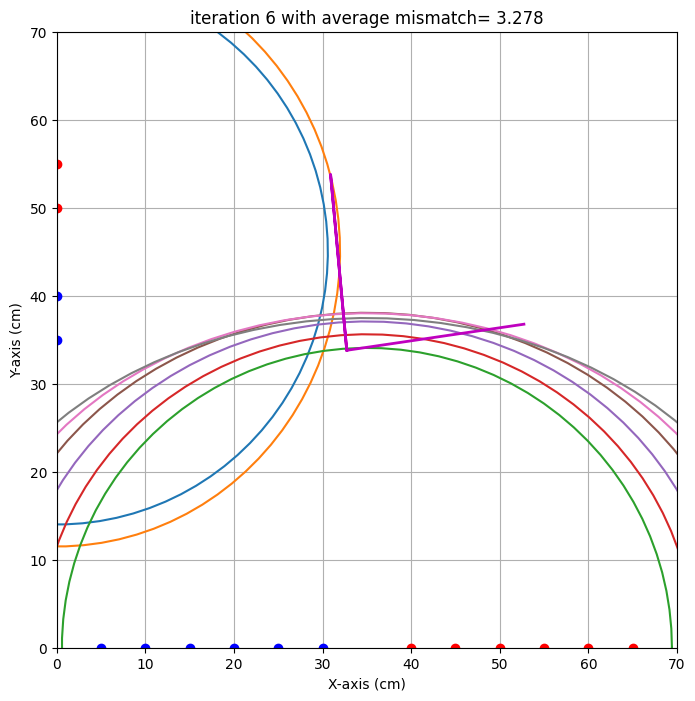

end iteration 6 with average mismatch= 3.278
end iteration 7 with average mismatch= 3.229


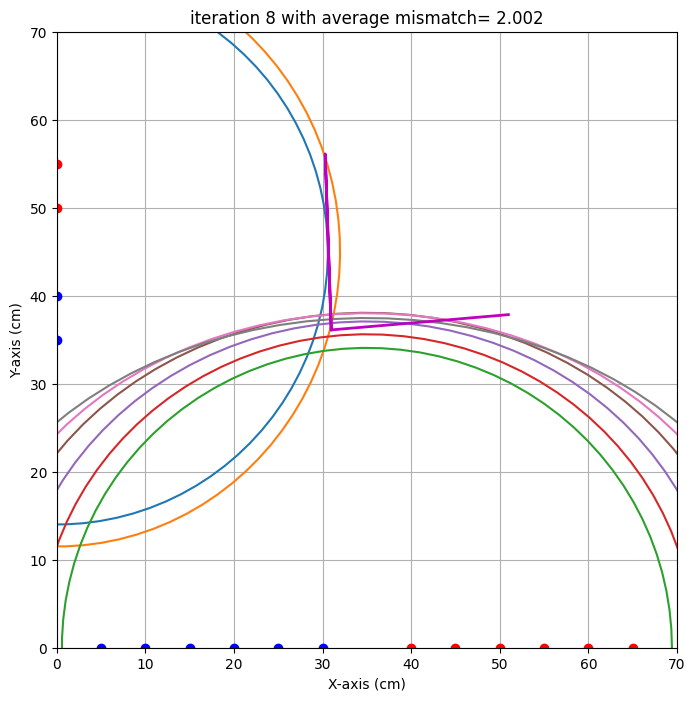

end iteration 8 with average mismatch= 2.002
end iteration 9 with average mismatch= 1.998
end iteration 10 with average mismatch= 1.994
end iteration 11 with average mismatch= 1.993
end iteration 12 with average mismatch= 1.988
end iteration 13 with average mismatch= 1.983
end iteration 14 with average mismatch= 1.982
end iteration 15 with average mismatch= 1.981
end iteration 16 with average mismatch= 1.981
end iteration 17 with average mismatch= 1.981
end iteration 18 with average mismatch= 1.981
end iteration 19 with average mismatch= 1.933
end iteration 20 with average mismatch= 1.933
end iteration 21 with average mismatch= 1.933
end iteration 22 with average mismatch= 1.933
end iteration 23 with average mismatch= 1.933
end iteration 24 with average mismatch= 1.933
end iteration 25 with average mismatch= 1.933
end iteration 26 with average mismatch= 1.933
end iteration 27 with average mismatch= 1.933
end iteration 28 with average mismatch= 1.933
end iteration 29 with average mismat

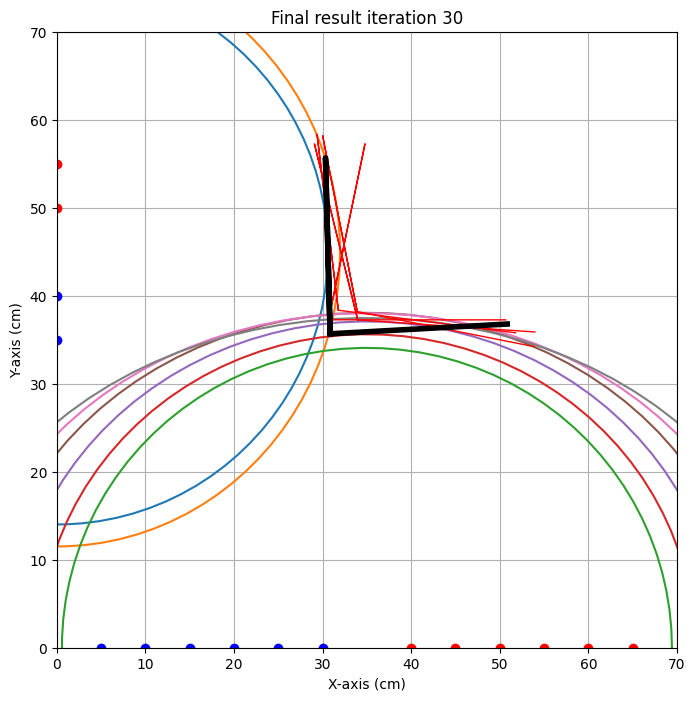

{'alpha': np.float64(3.181187608967795), 'alpha_eps': np.float64(14.455477671652842), 'beta': np.float64(-1.4919867694250224), 'beta_eps': np.float64(13.133202165552959), 'x0': np.float64(30.8449485466993), 'x0_eps': np.float64(3.119293324239706), 'y0': np.float64(35.67228026940313), 'y0_eps': np.float64(2.6773438710172215)}
locatie 1 
x0 target is : 27.0. Gevonden waarde: 30.8 cm met een standaardafwijking van 3.1 cm 
y0 target is : 35.0. Gevonden waarde: 35.7 cm met een standaardafwijking van 2.7 cm 
alpha target is : -26.0. Gevonden waarde: 3.2 graden met een standaardafwijking van 14.5 graad 
beta target is : 20.0. Gevonden waarde: -1.5 graden met een standaardafwijking van 13.1 graad 



In [58]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 27,
                    'y0': 35,
                    'alpha' : -26,
                    'beta' : 20,                  
           'locatie 2':{'x0':34,
                    'y0':34,
                    'alpha' :34, 
                    'beta' :34, 
            }}}
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # [0,40,0,30,ongeldig],
    [0,50,0,40,62],
    [0,55,0,35,67],
    #[0,60,0,30,ongeldig],
    [40,0,30,0,68.88],
    [45,0,25,0,74.0],
    [50,0,20,0,80],
    [55,0,15,0,86],
    [60,0,10,0,91],
    [65,0,5,0,96],
    # zelf aanvullen
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

In [ ]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':  # zelf aanvullen,
                    'y0':  # zelf aanvullen,
                    'alpha' :  # zelf aanvullen,
                    'beta' :  # zelf aanvullen
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    # zelf aanvullen
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

SyntaxError: invalid syntax (598375666.py, line 7)

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")